In [1]:

import pwbarycentres as pwb
from graph_dp import SinkhornDataProcessor
import numpy
import torch
from utils import *
import matplotlib.pyplot as plt

In [2]:
! gpustat

nvidia6                     Mon Feb 16 18:07:45 2026  550.90.07
[0] NVIDIA GeForce RTX 3090 | 26°C,   0 % |     3 / 24576 MB |
[1] NVIDIA GeForce RTX 3090 | 29°C,   0 % | 22804 / 24576 MB | ij23(22798M)
[2] NVIDIA GeForce RTX 3090 | 26°C,   0 % |     3 / 24576 MB |
[3] NVIDIA GeForce RTX 3090 | 49°C,  86 % |   943 / 24576 MB | mmy20(336M) mmy20(598M)
[4] NVIDIA GeForce RTX 3090 | 46°C, 100 % | 12630 / 24576 MB | mmy20(12624M)
[5] NVIDIA GeForce RTX 3090 | 27°C,   0 % |     3 / 24576 MB |
[6] NVIDIA GeForce RTX 3090 | 47°C,  13 % |   384 / 24576 MB | jcz21(378M)
[7] NVIDIA GeForce RTX 3090 | 27°C,   0 % |     3 / 24576 MB |


In [3]:
cuda = 5

device = 'cuda:{}'.format(cuda)


## Clustering 1 per event

In [4]:

# # I should abstract this...
# times = [0, 1, 2, 3, 4]
# members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# clusters = [50, -50, -50, -50, -50, -50, -50, -50, -50, -50]
# path_to_data = '/home/jjf817/macomp001/jjf817/PhD_jobs/ICP_Cases/MescoVict_cases/'

# # Gather time series data
# data_list = []
# dictionary_in_time = {}
# for t in times:
#     data_list = []
#     for k, mem in enumerate(members):
#         cluster = clusters[k]
#         F, X = generate_circle_ensemble(mem, 20, path_to_data, seed_pert=17*(t+1))
#         F = np.roll(F, cluster, axis=1)

#         data_list.append([F, None])
    
#     # shuffle over a member
#     clusters[t+1] = 50
#     cluster = -50
#     O, X = generate_circle_ensemble(mem, 20, path_to_data, seed_pert=17)
#     O = np.roll(O, cluster, axis=1)

#     dictionary_in_time[t] = dict(
#         observation = [O, None],
#         forecasts = data_list
#         )

In [5]:
# set 1
with open('/home/jjf817/PhD_jobs/simple_barycentres/ensemble_data/ensemble_dataset_1.pkl', 'rb') as f:
    dictionary_in_time = pickle.load(f)

In [6]:
data_list = dictionary_in_time[0]['forecasts']
X = dictionary_in_time['grid']

In [ ]:
# one normal comparison
# epsilon = 0.1 
# eps_0.005_rho_0.001_aprox_kl_
debiasing = True
N = 100
epsilon = 1/N
epsilon = 0.005
rho = 1.0
tol = 1e-5
aprox= 'kl'  # balanced or unbalanced
lags= {'barycentre':1, 'debiasing':1}
max_iterates=50
annealing = False
device = 3

epsilon = torch.tensor([epsilon]).to(device=device, dtype=torch.float64)

# Generate data holding class
data_processor = pwb.generate_barycentredataprocessor(
    data_list,
    barycentre_grid=X,
    grid=X, 
    weights=None, 
    cuda_device=f'cuda:{device}',
    potentials='f'
)


In [8]:

data_processor, barycentre, potential_error_list, barycentre_error_list, constraint_dict = (
    pwb.asymmetric_sinkhorn_log_algorithm(
                    data_processor,
                    epsilon=epsilon,
                    rho=rho,
                    aprox=aprox,
                    max_iterates=max_iterates,
                    tol=tol,
                    epsilon_annealing=annealing,
                    debiasing=debiasing,
                    verbose=False,
                    measure_constraints=True,
                    lags=lags
                )
)


Text(0.5, 0.98, "Barycentre of multimodal Gaussians epsilon=0.004999999888241291, rho=1.0, debiasing=True, lags={'barycentre': 1, 'debiasing': 1}, tol=1e-05, aprox=kl")

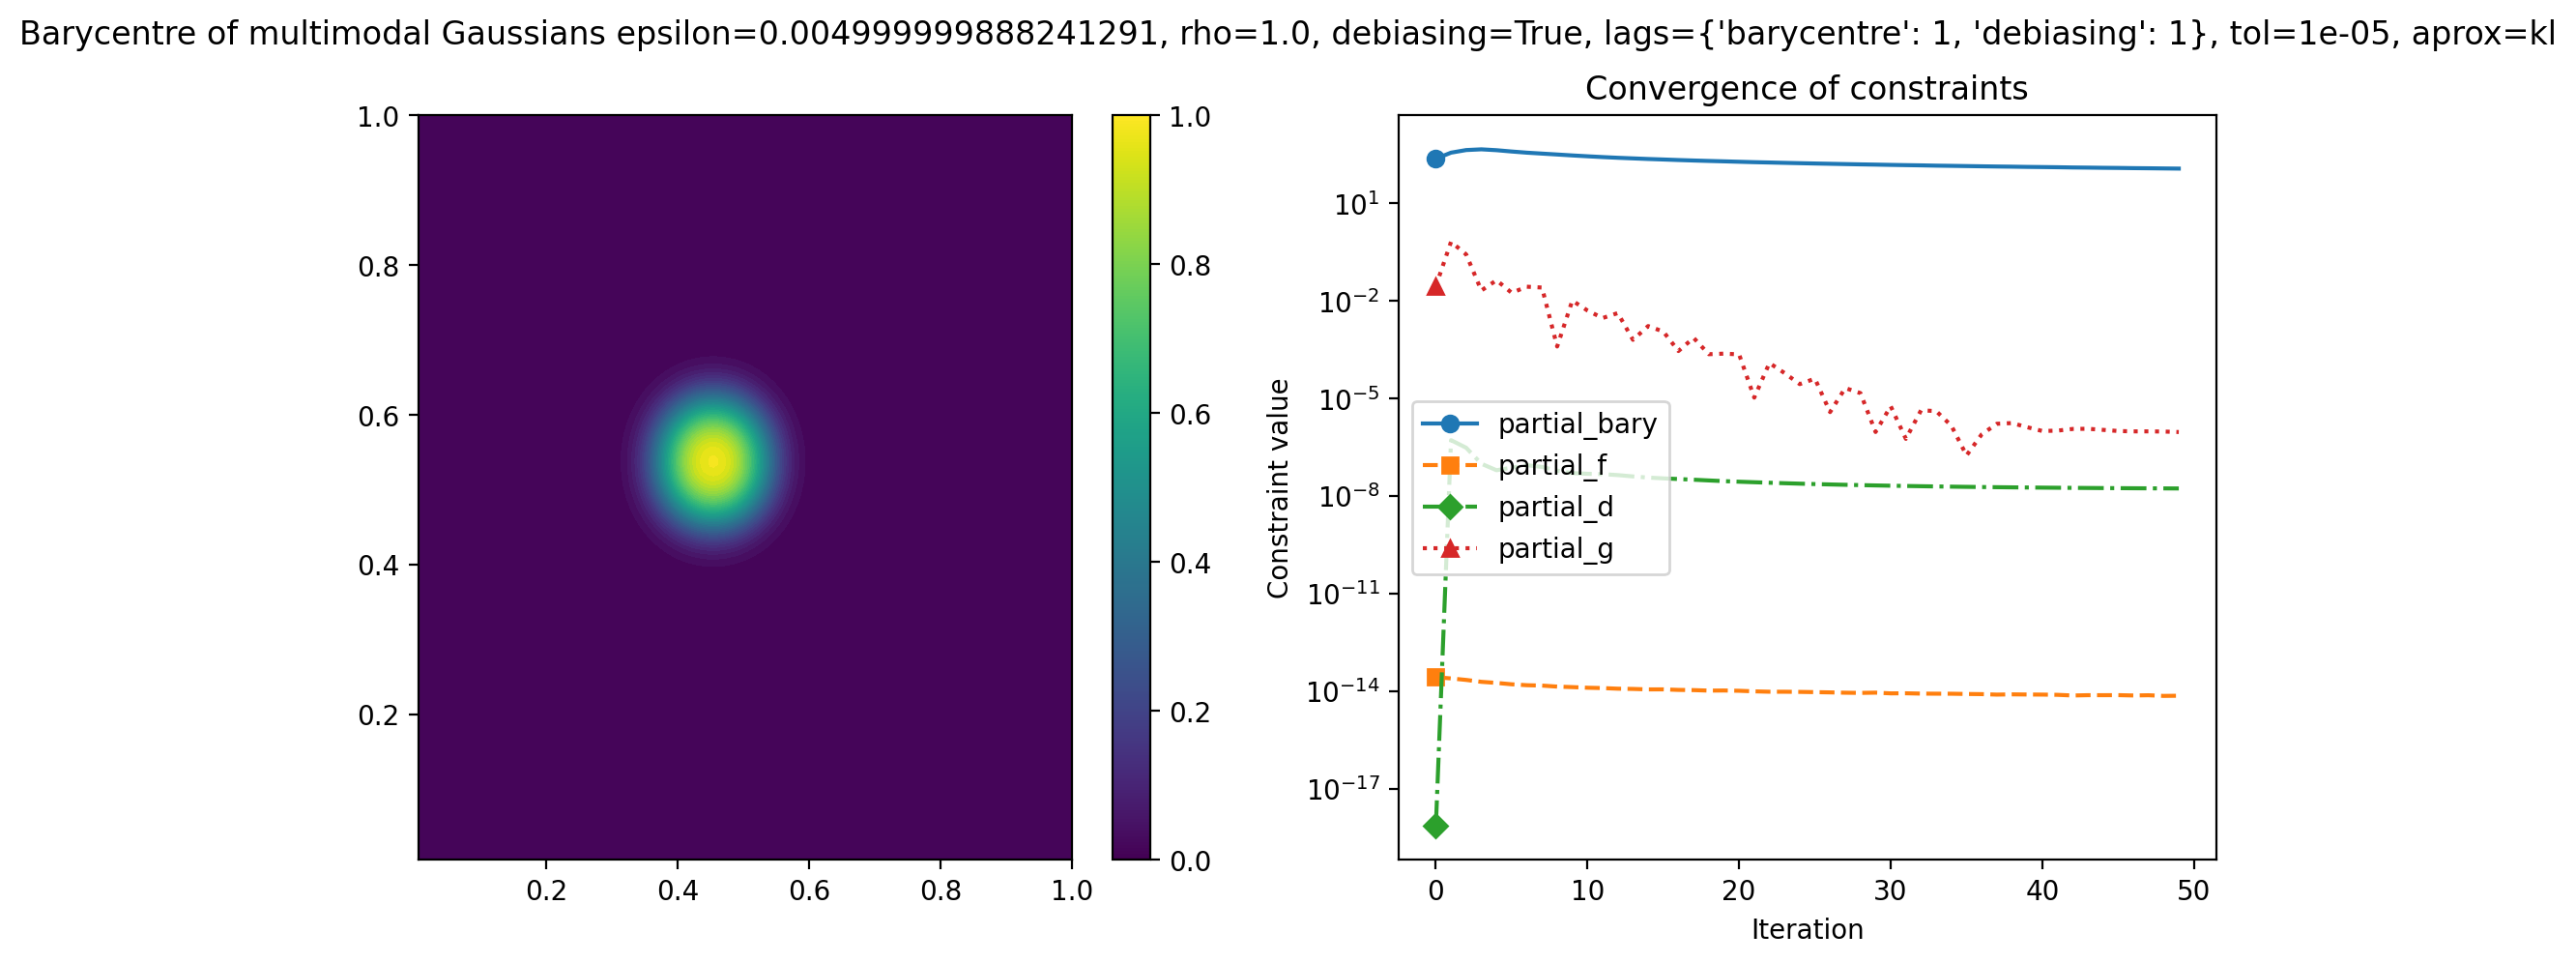

In [9]:
# plot the barycentre
fig, ax  =  plt.subplots(1, 2, figsize=(12,5), dpi=200)


ax[0].contourf(X[:, :, 0], X[:, :,1], barycentre.cpu().numpy(), 50)
fig.colorbar(ax[0].collections[0], ax=ax[0])

styles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^']
for key, s, m in zip(constraint_dict, styles, markers):
    ax[1].plot([abs(k) for k in constraint_dict[key]], label=key, linestyle=s, marker=m, markevery=100)
ax[1].set_yscale('log')
ax[1].set_xlabel('Iteration')
ax[1].set_ylabel('Constraint value')
ax[1].set_title('Convergence of constraints')
ax[1].legend()

plt.suptitle('Barycentre of multimodal Gaussians epsilon={}, rho={}, debiasing={}, lags={}, tol={}, aprox={}'.format(epsilon.item(), rho, debiasing, lags, tol, aprox))

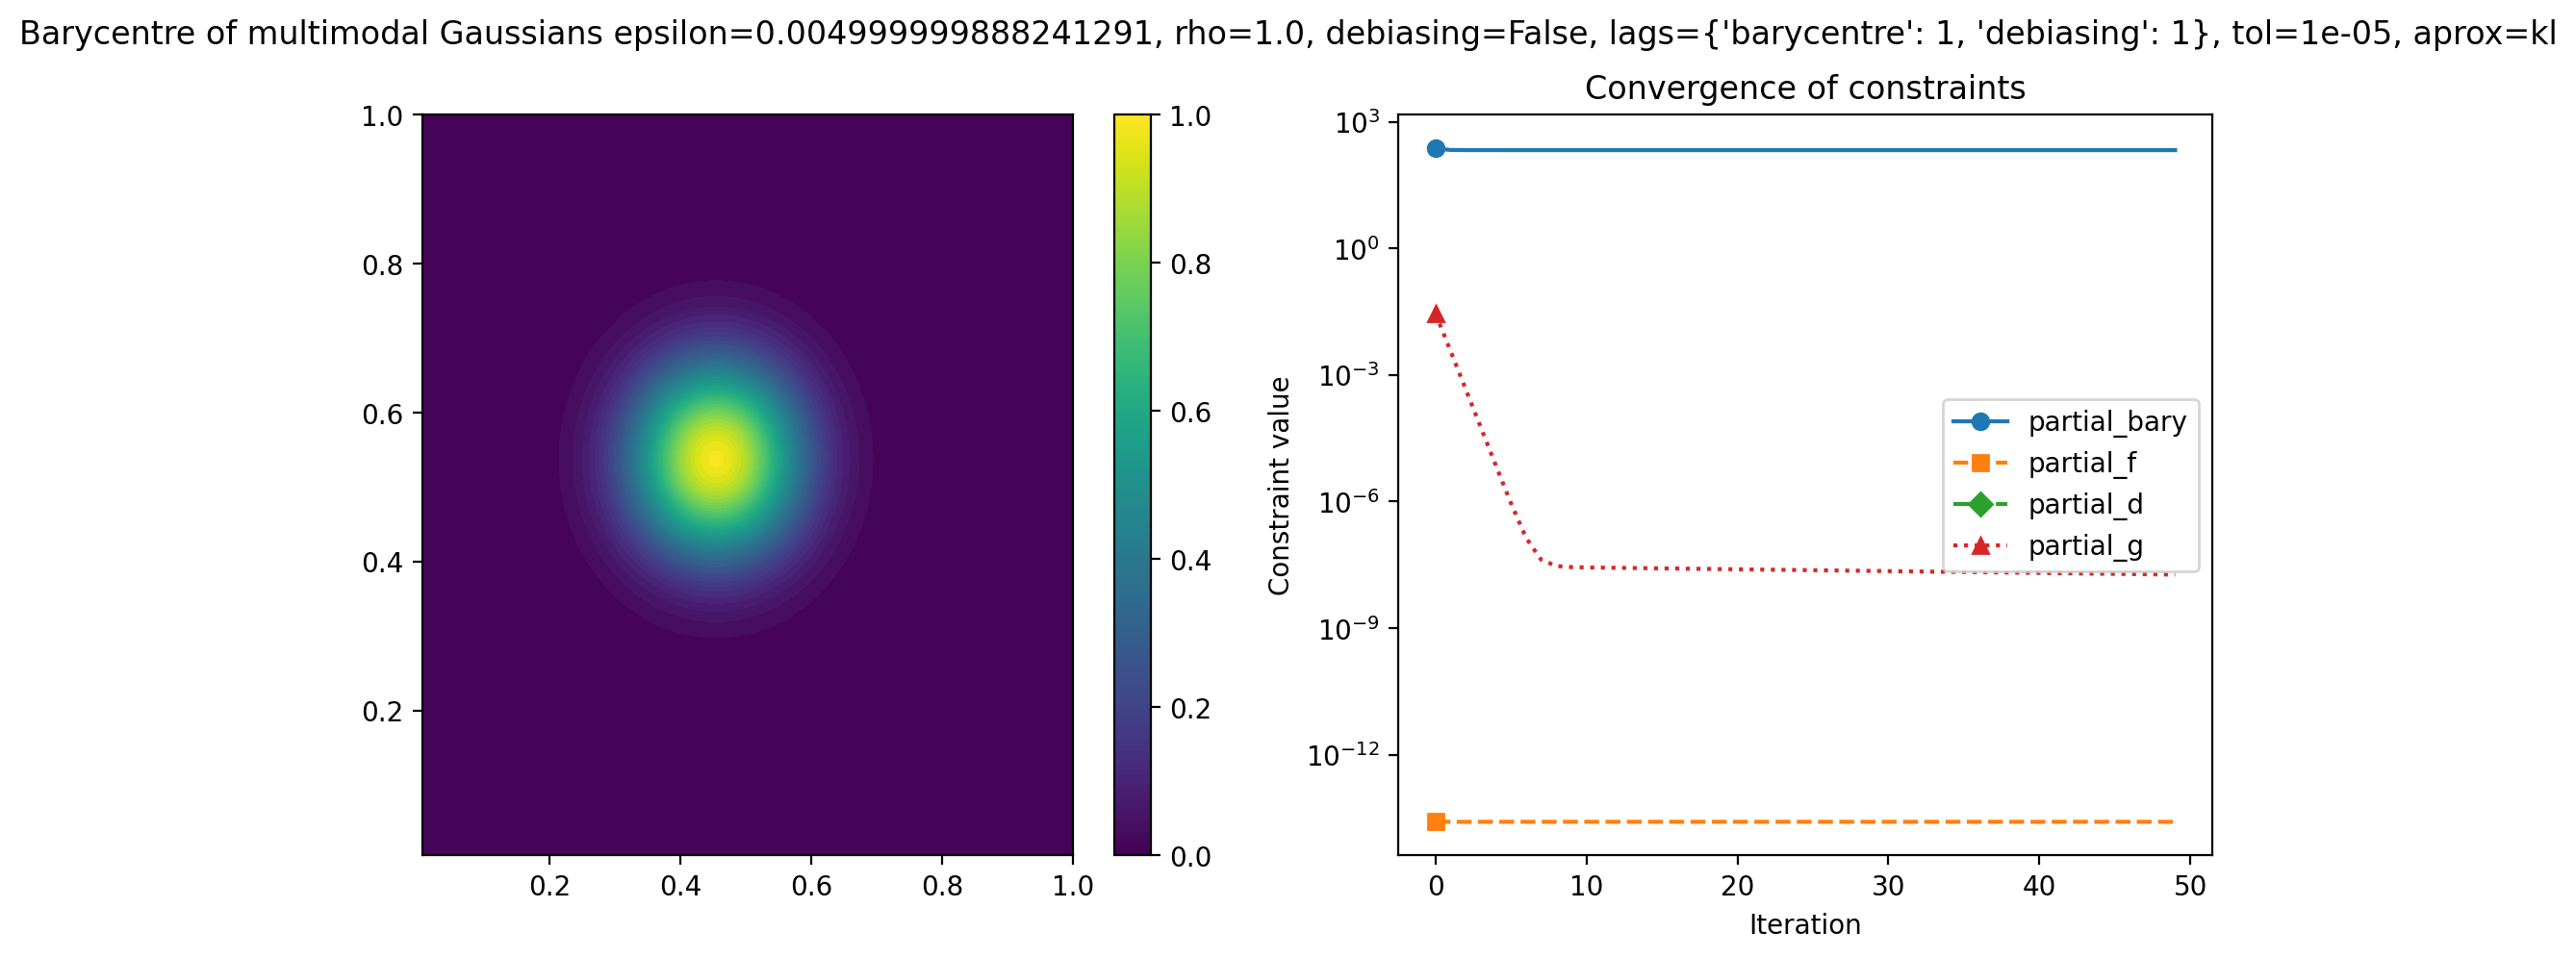

In [8]:
potential_error_list[-5:], barycentre_error_list[-5:]


([0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0])

In [9]:
for key in constraint_dict:
    print(f"{key}: {constraint_dict[key][-1]}")

partial_bary: -951.6750000000001
partial_f: 5.547996275549581e-15
partial_d: 0.0
partial_g: 1.9865127053486258e-22


In [10]:
assert 0

AssertionError: 

# seeing is debiaing was doing anything

In [3]:
import pickle
with open('/home/jjf817/PhD_jobs/simple_barycentres/pkl/1/barycentres_costs_eps_0.005_rho_0.001_aprox_kl_debiasing_True.pkl', 'rb') as f:
    data_false = pickle.load(f)

with open('/home/jjf817/PhD_jobs/simple_barycentres/pkl/1/barycentres_costs_eps_0.005_rho_1.0_aprox_kl_debiasing_False.pkl', 'rb') as f:
    data_true = pickle.load(f)


In [9]:
print(data_false[1])
data_true[1]

[{'total_cost': nan, 'unbalanced_sinkhorn_terms': [0.0005711956852057666, 0.0005710359377854647, 0.0005713415142636035, 0.000570876172068659, 0.0005708062182733948, 0.00057101664319512, 0.0005706525897077058, 0.0005712276358308013, 0.0005715983661648909, 0.0005711213285101527], 'uot_mu_mu_terms': [1.3986224878906996e-05, 1.3986224876225027e-05, 1.3986224876938812e-05, 1.3986224876907398e-05, 1.3986224876023684e-05, 1.3986224875940109e-05, 1.3986224875951634e-05, 1.3986224875961554e-05, 1.3986224877369375e-05, 1.3986224876113666e-05], 'debiasing_term': nan, 'epsilon': 0.005, 'rho': 0.001, 'aprox': 'kl', 'debiasing': 'True'}, {'partial_bary': [-479.5844900229577, -457.784915965692, -381.1423535355635, -340.7709610774474, -315.64811438534366, -298.124565218013, -285.5255308722155, -275.1762897533975, -265.8269970777007, -258.02755390963415, -250.5280944267298, -244.30352344425563, -238.42895412260705, -232.929317806442, -228.57961257055217, -223.55500239256742, -219.45529176386492, -215.6

[{'total_cost': nan,
  'unbalanced_sinkhorn_terms': [0.0029329620747625307,
   0.0028497835324626302,
   0.0030133354920262334,
   0.0027602960490307783,
   0.002721592138952248,
   0.0028350721986414415,
   0.0026396294147147835,
   0.002946618719101348,
   0.0031488581858952844,
   0.0028902336729854845],
  'uot_mu_mu_terms': [1.3986206462871577e-05,
   1.3986206462864501e-05,
   1.398620646286699e-05,
   1.3986206462866173e-05,
   1.3986206462863066e-05,
   1.3986206462863066e-05,
   1.3986206462863066e-05,
   1.3986206462863246e-05,
   1.3986206462868437e-05,
   1.3986206462863566e-05],
  'debiasing_term': nan,
  'epsilon': 0.005,
  'rho': 1.0,
  'aprox': 'kl',
  'debiasing': 'False'},
 {'partial_bary': [-383.7466011166164,
   -382.36719839147383,
   -316.4687714674322,
   -283.5466819129262,
   -261.52541121280353,
   -239.67842740082259,
   -221.85490172632728,
   -212.73019668883333,
   -208.20542451440176,
   -202.7060519593687,
   -196.15679154944203,
   -190.8822121021705,
  

In [6]:
for i in range(len(data_false)):
    print(data_false[i].sum(), data_true[i].sum())

tensor(0.7023, device='cuda:2', dtype=torch.float64) tensor(0.7023, device='cuda:2', dtype=torch.float64)
tensor(0.7023, device='cuda:2', dtype=torch.float64) tensor(0.7023, device='cuda:2', dtype=torch.float64)
tensor(0.8091, device='cuda:2', dtype=torch.float64) tensor(0.8091, device='cuda:2', dtype=torch.float64)
tensor(0.8210, device='cuda:2', dtype=torch.float64) tensor(0.8210, device='cuda:2', dtype=torch.float64)


In [7]:
(data_true[0].cpu() == data_false[0].cpu()).any()

tensor(True)

# below im no sure


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_debiasing(dp, list, eps, X, Y, n_iter=50):
    """
    Animate evolution of the debiasing dual potential.
    """
    # initial potential
    d = list[0]

    # build figure
    fig, ax = plt.subplots(figsize=(8,6))
    cs = ax.contourf(X, Y, d, 200)
    cbar = plt.colorbar(cs, ax=ax)
    ax.set_title("Debiasing Dual Potential (t=0)")

    # ------ update function ------
    def update(frame):
        nonlocal d  # allow modification of d in outer scope
        d = list[frame]

        ax.clear()
        cs = ax.contourf(X, Y, d, 200)
        ax.set_title(f"(t={frame})")
        return cs.collections

    # build animation
    anim = FuncAnimation(fig, update, frames=n_iter, interval=150, blit=False)
    return anim


In [ ]:
len(bary_list)

563

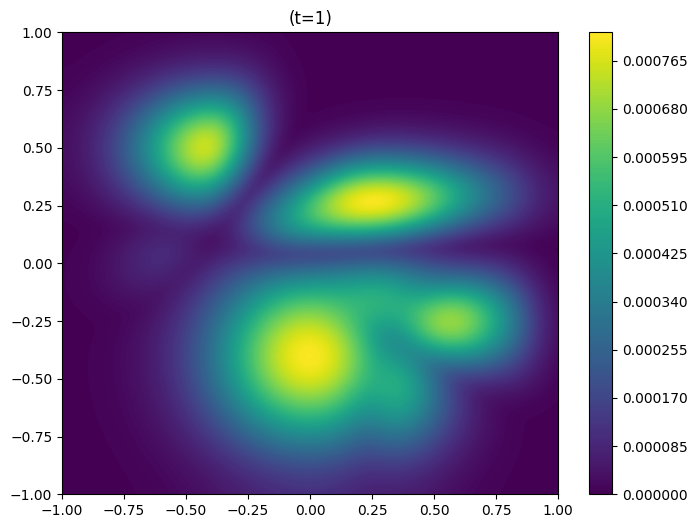

In [ ]:
anim = animate_debiasing(dp, d_list, eps, X, Y, n_iter=list(range(1, len(bary_list), 5)))
anim.save("debiasing_evolution_throughout.mp4", fps=10, dpi=120)

# generating plots:

7) DataProcessor generated for barycentre computation
8) Barycentre computation complete 175266742807.5 9.825240974953948e-10


Text(0.5, 0.98, 'debaising = False eps =0.0050, rho=10, its 216, err=0.0000')

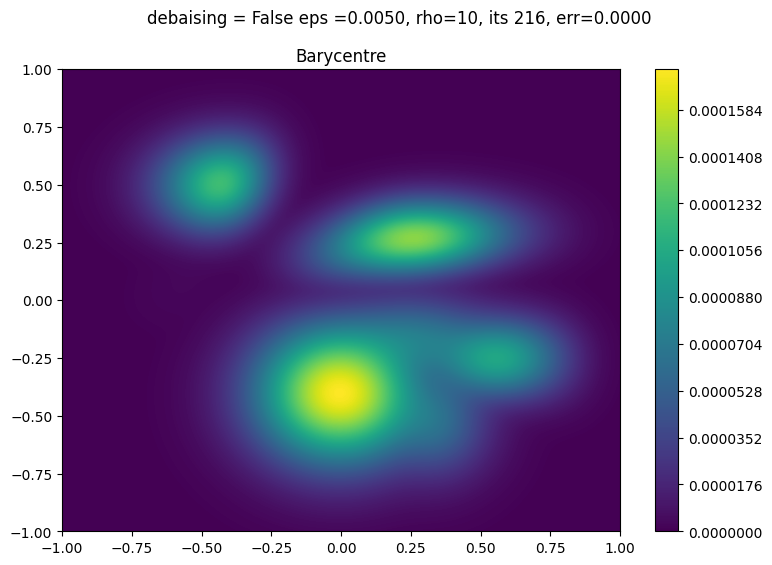

In [ ]:
## one normal comparison
# epsilon = 0.1
rho = 10
debiasing = False
N = 200
epsilon = 1/N


grid_tuple = (torch.linspace(-1, 1, N), torch.linspace(-1, 1, N))
density2, (X, Y) = multimodal_gaussian_2d(means2, stds2, N, amplitudes=amps2)
density1, (X, Y) = multimodal_gaussian_2d(means1, stds1, N, amplitudes=amps1)

# ==================================================================
# RUN THE BARYCENTRE COMPUTATION
# =================================================================

epsilon = torch.tensor([epsilon]).to(device=device, dtype=dtype)

# Generate data holding class
data_processor = pwb.generate_barycentredataprocessor(
    [[density1/density1.sum(), None], [density2/density2.sum(), None]], 
    barycentre_grid=grid_tuple,
    grid=grid_tuple, 
    weights=None, 
    cuda_device=f'cuda:{cuda}'
)
print("7) DataProcessor generated for barycentre computation")

t2 = process_time()
data_processor, barycentre, potential_error_list, barycentre_error_list = (
    pwb.asymmetric_sinkhorn_algorithm(
        data_processor,
        epsilon=epsilon,
        rho=rho,
        aprox='balanced',
        max_iterates=7000,
        tol=1e-9,
        epsilon_annealing=False,
        debiasing=debiasing,
        debiasing_update_freq=-10
    )
)
t3 = process_time()

# errinf, errp1 = pwb.d_constraint(data_processor.data_dict[0]['debiased_potential'], epsilon, data_processor)
# print("Debiasing constraint errors (inf, p1): ", errinf.item(), errp1.item())

print("8) Barycentre computation complete", potential_error_list[-1], barycentre_error_list[-1])

fig = plt.figure(figsize=(9,6))

ax = fig.add_subplot(111)
p = ax.contourf(X, Y, barycentre.cpu(), 500)#, norm=LogNorm())
plt.colorbar(p, ax=ax)
ax.set_title("Barycentre")

# ax = fig.add_subplot(122)
# p = ax.contourf(X, Y, (density1/density1.sum() + density2/density2.sum()) / 2, 500)
# plt.colorbar(p, ax=ax)
# ax.set_title("Ensemble Mean")

plt.suptitle(f'debaising = {debiasing} eps ={epsilon.item():.4f}, rho={rho}, its {len(potential_error_list)}, err={barycentre_error_list[-1]:.4f}')

# plt.savefig('figs/linkedbarycentre_debiasing{}_eps{}_rho{}_N{}_balanced.png'.format(debiasing, epsilon.item(), rho, N))

In [ ]:
# checks
suot, cost = pwb.asymmetric_cost(data_processor,
    epsilon,
    rho,
    aprox='balanced',
    debiasing=False,
    verbose=False)

marginal_output = pwb.ot_marginals(
    data_processor,
    epsilon,
    debiasing=False
)

In [ ]:
suot.item(), [c.item() for c in cost]

(58767.1998808869, [29383.60036252117, 29383.599518365732])

In [ ]:
for k in marginal_output.keys():
    print('MARGINAL CHECK', k, marginal_output[k]['error'], marginal_output[k]['marginal'].sum().item())

MARGINAL CHECK 0 1.3719274576437903e-08 1.0000000010114123
MARGINAL CHECK 1 7.972228529184913e-12 1.0000000010114123
MARGINAL CHECK 2 1.3719274576437903e-08 1.0000000010114123
MARGINAL CHECK 3 5.521900292701151e-12 1.0000000010114123


In [ ]:
for N in [100, 200, 400]:
    print(1/N)

0.01
0.005
0.0025


In [ ]:
from matplotlib.colors import LogNorm

In [ ]:
# epsilon = 0.1
rho = 10
debiasing = True
for debiasing in [True]:
    for N in [50, 100, 200, 400]:
        print(f"Running for grid size N={N}")
        for epsilon in [10/N, 1/N, 0.1/N, 0.05/N]:
            print(f"  Epsilon: {epsilon}")

            grid_tuple = (torch.linspace(-1, 1, N), torch.linspace(-1, 1, N))
            density2, (X, Y) = multimodal_gaussian_2d(means2, stds2, N, amplitudes=amps2)
            density1, (X, Y) = multimodal_gaussian_2d(means1, stds1, N, amplitudes=amps1)

            # ==================================================================
            # RUN THE BARYCENTRE COMPUTATION
            # =================================================================

            epsilon = torch.tensor([epsilon]).to(device=device, dtype=dtype)

            # Generate data holding class
            data_processor = pwb.generate_barycentredataprocessor(
                [[density1/density1.sum(), None], [density2/density2.sum(), None]], 
                barycentre_grid=grid_tuple,
                grid=grid_tuple, 
                weights=None, 
                cuda_device=f'cuda:{cuda}'
            )
            print("7) DataProcessor generated for barycentre computation")

            t2 = process_time()
            data_processor, barycentre, potential_error_list, barycentre_error_list = (
                pwb.asymmetric_sinkhorn_algorithm(
                    data_processor,
                    epsilon=epsilon,
                    rho=rho,
                    aprox='balanced',
                    max_iterates=7000,
                    tol=1e-9,
                    epsilon_annealing=False,
                    debiasing=debiasing,
                )
            )
            t3 = process_time()

            # errinf, errp1 = pwb.d_constraint(data_processor.data_dict[0]['debiased_potential'], epsilon, data_processor)
            # print("Debiasing constraint errors (inf, p1): ", errinf.item(), errp1.item())

            print("8) Barycentre computation complete", potential_error_list[-1], barycentre_error_list[-1])

            fig = plt.figure(figsize=(9,6))

            ax = fig.add_subplot(111)
            p = ax.contourf(X, Y, barycentre.cpu(), 500)#, norm=LogNorm())
            plt.colorbar(p, ax=ax)
            ax.set_title("Barycentre")

            # ax = fig.add_subplot(122)
            # p = ax.contourf(X, Y, (density1/density1.sum() + density2/density2.sum()) / 2, 500)
            # plt.colorbar(p, ax=ax)
            # ax.set_title("Ensemble Mean")

            plt.suptitle(f'debaising = {debiasing} eps ={epsilon.item():.4f}, rho={rho}, its {len(potential_error_list)}, err={barycentre_error_list[-1]:.4f}')

            plt.savefig('figs/linkedbarycentre_debiasing{}_eps{}_rho{}_N{}_balanced.png'.format(debiasing, epsilon.item(), rho, N))

In [ ]:
output = pwb.ot_marginals(data_processor, epsilon, debiasing=debiasing)

NameError: name 'data_processor' is not defined

In [ ]:
for k in output.keys():
    print(k, output[k]['error'], output[k]['marginal'].sum())

In [ ]:
# plot two error curves 
plt.figure(figsize=(10,5))
plt.plot(potential_error_list, label='Potential Error')
plt.plot(barycentre_error_list, label='Barycentre Error')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Convergence of Asymmetric Sinkhorn Barycentre Algorithm')
plt.legend()
plt.show()

Running N=50, epsilon=0.025
Running N=50, epsilon=0.0025
Running N=50, epsilon=0.00025
Running N=50, epsilon=0.000125
Running N=100, epsilon=0.025
Running N=100, epsilon=0.0025
Running N=100, epsilon=0.00025
Running N=100, epsilon=0.000125
Running N=200, epsilon=0.025
Running N=200, epsilon=0.0025
Running N=200, epsilon=0.00025
Running N=200, epsilon=0.000125
Running N=400, epsilon=0.025
Running N=400, epsilon=0.0025
Running N=400, epsilon=0.00025
Running N=400, epsilon=0.000125


/tmp/ipykernel_3896715/3732233216.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


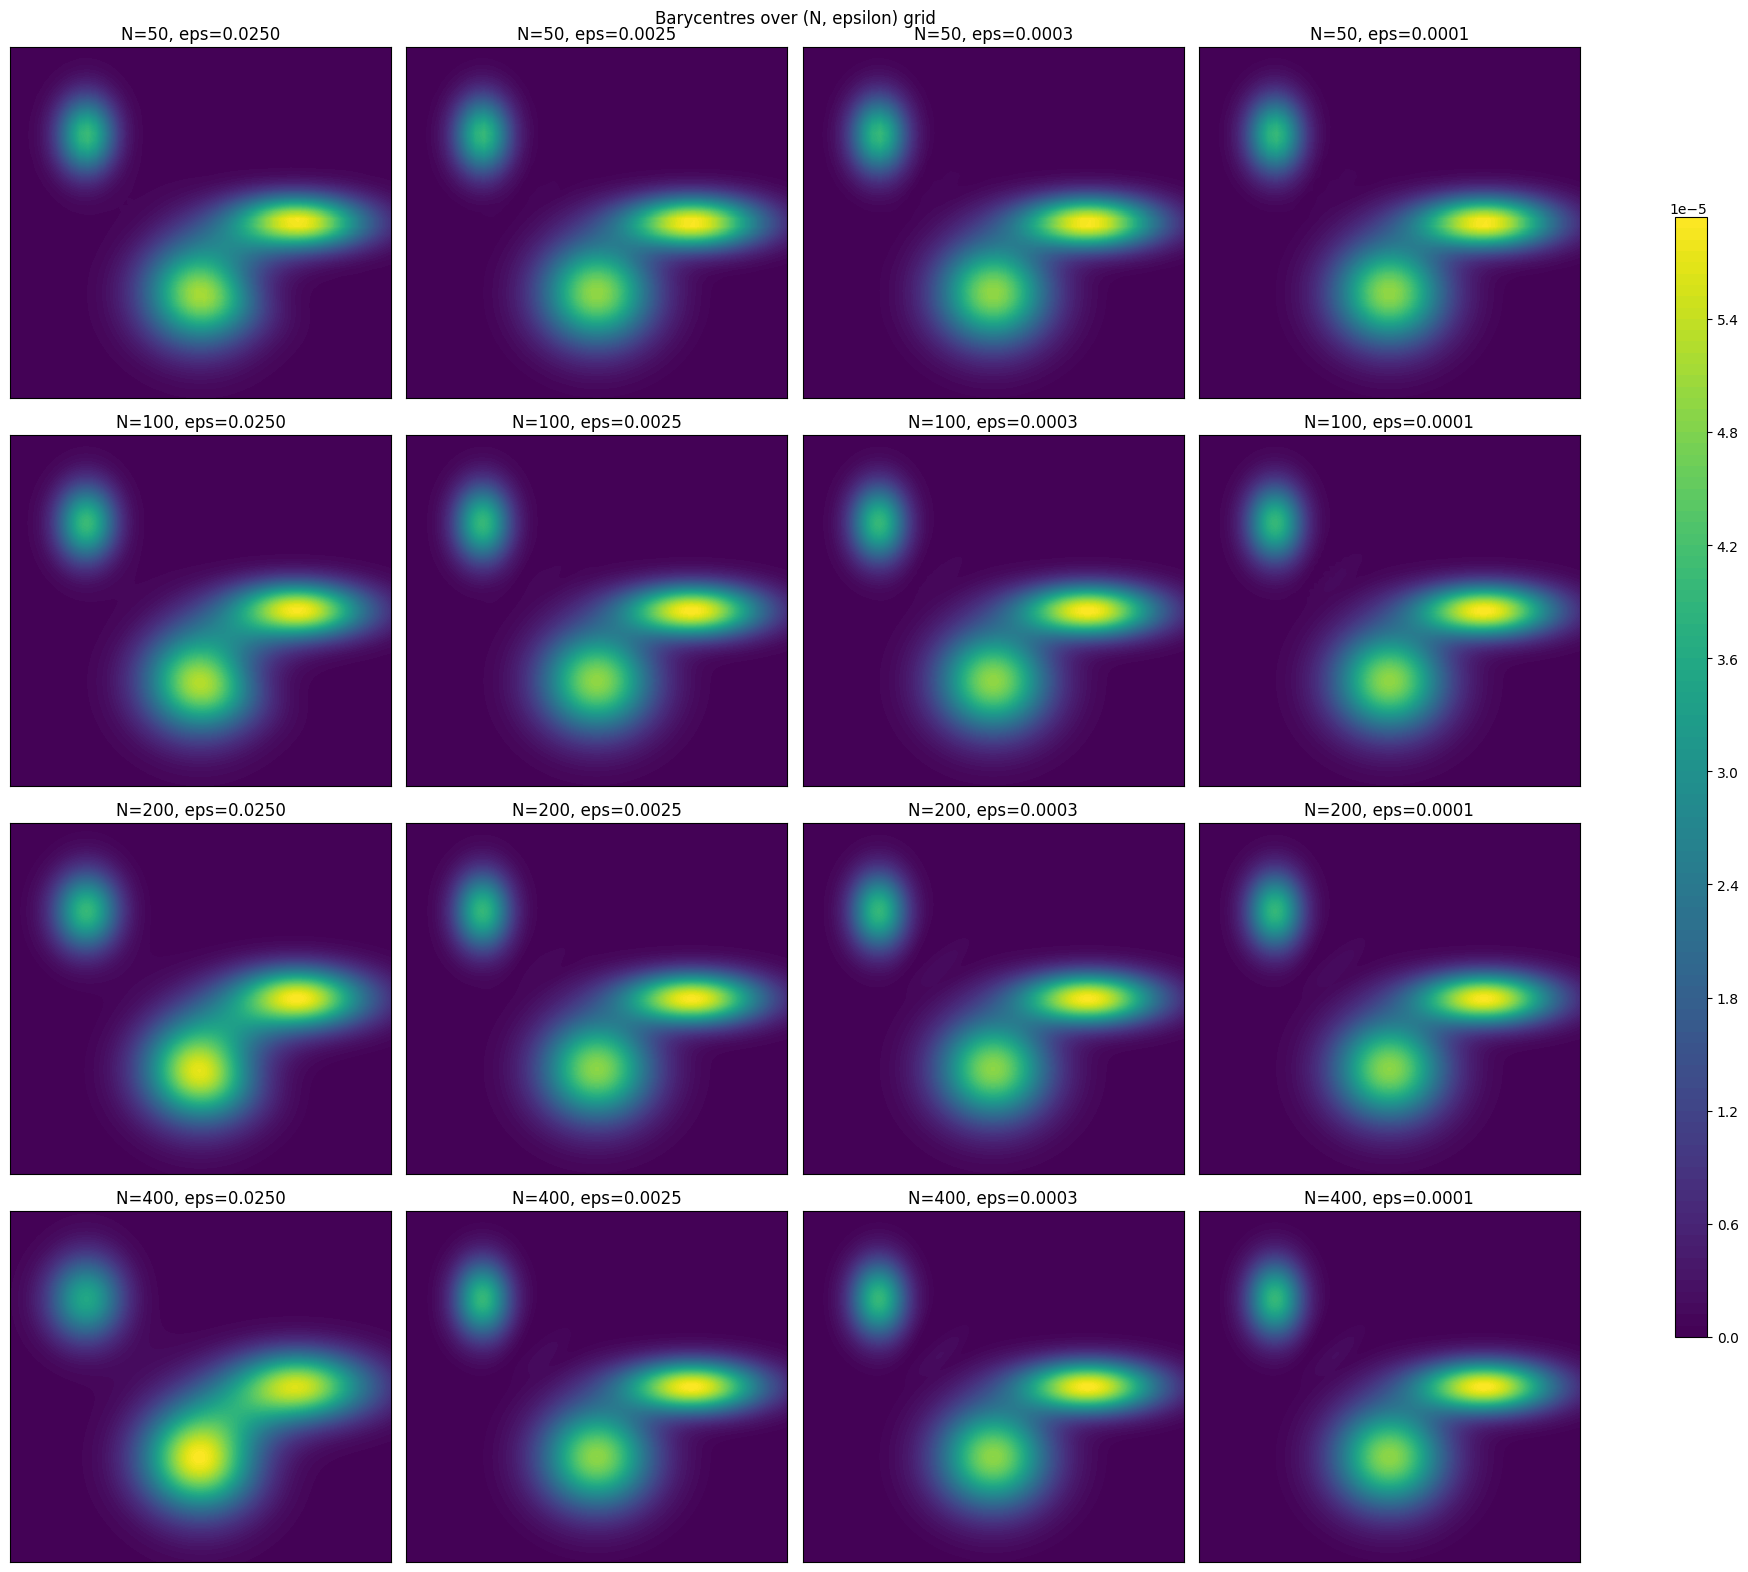

In [ ]:
import matplotlib.pyplot as plt

N_list = [50, 100, 200, 400]
eps_list = [10/N, 1/N, 0.1/N, 0.05/N]

fig, axes = plt.subplots(len(N_list), len(eps_list), figsize=(4*len(eps_list), 4*len(N_list)))

for i, N in enumerate(N_list):
    for j, eps in enumerate(eps_list):

        print(f"Running N={N}, epsilon={eps}")

        # ---- Compute density + barycentre (your code) ----
        grid_tuple = (torch.linspace(-1, 1, N), torch.linspace(-1, 1, N))
        density2, (X, Y) = multimodal_gaussian_2d(means2, stds2, N, amplitudes=amps2)
        density1, (X, Y) = multimodal_gaussian_2d(means1, stds1, N, amplitudes=amps1)

        epsilon = torch.tensor([eps]).to(device=device, dtype=dtype)

        data_processor = pwb.generate_barycentredataprocessor(
            [[density1/density1.sum(), None], [density2/density2.sum(), None]], 
            barycentre_grid=grid_tuple,
            grid=grid_tuple,
            cuda_device=f'cuda:{cuda}'
        )

        data_processor, barycentre, potential_error_list, barycentre_error_list = (
            pwb.asymmetric_sinkhorn_algorithm(
                data_processor,
                epsilon=epsilon,
                rho=10,
                aprox='balanced',
                max_iterates=7000,
                tol=1e-9,
                debiasing=True,
                debiasing_update_freq=10
            )
        )

        # ---- Plot in the right subplot ----
        ax = axes[i, j]   # pick correct subplot
        cs = ax.contourf(X, Y, barycentre.cpu(), 100)
        ax.set_title(f"N={N}, eps={eps:.4f}")
        ax.set_xticks([])
        ax.set_yticks([])

# Add ONE shared colorbar
cbar_ax = fig.add_axes([1.05, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cs, cax=cbar_ax)

fig.suptitle("Barycentres over (N, epsilon) grid")
plt.tight_layout()
plt.savefig("figs/barycentre_grid.png")
plt.show()


d%10: -29362.995936560346
d%1: -29362.999772136314



In [ ]:
# plot two error curves 
plt.figure(figsize=(10,5))
plt.plot(cost_list, label='Potential Error')
# plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Convergence of Asymmetric Sinkhorn Barycentre Cost')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_barycentres(barycentres, X, Y, interval=120, skip=100, frames = None):
    """
    Animate sequence of barycentres on mesh (X,Y).
    barycentres: list or array of shape [T, N, N]
    """

    fig, ax = plt.subplots(figsize=(5,4))

    # initial frame
    p = ax.contourf(X, Y, barycentres[0], 200)
    cb = plt.colorbar(p, ax=ax)

    ax.set_title("Barycentre t=0")

    # to update contourf properly we clear and redraw
    def update(frame):
        ax.clear()
        p = ax.contourf(X, Y, barycentres[frame], 200)
        ax.set_title(f"Barycentre t={frame}")
        return p.collections
    
    if frames is None:
        frames = list(range(0, len(barycentres), skip))

    anim = FuncAnimation(fig, update, frames=frames,
                         interval=interval, blit=False)

    return anim


In [ ]:
anim = animate_barycentres(bary_list, X, Y, interval=120, frames=list(range(0,50)))

In [ ]:
from IPython.display import HTML
HTML(anim.to_jshtml())
